In [1]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from qiskit import QuantumCircuit, __version__
from qiskit.visualization import plot_histogram, plot_distribution
from qiskit.visualization import visualize_transition
from qiskit_aer import Aer  # ✅ works with qiskit-aer installed
import matplotlib.pyplot as plt
import numpy as np

print(__version__)

0.45.0


In [2]:
backend = Aer.get_backend("aer_simulator")


In [3]:
breast_df = pd.read_csv("data.csv")

breast_df.columns = breast_df.columns.str.strip()

breast_df["diagnosis"] = breast_df["diagnosis"].map({"M": 1, "B": 0})

breast_df = breast_df.dropna(subset=["diagnosis"])

breast_df = breast_df.drop(columns=["id", "Unnamed: 32"], errors="ignore")

X = breast_df.drop(columns=["diagnosis"]).values
y = breast_df["diagnosis"].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled = X_scaled[:, :4]

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (455, 4)
y_train shape: (455,)


In [4]:
rf_model = RandomForestClassifier(n_estimators = 100, random_state = 42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)
print("🎯 Random Forest Accuracy:", accuracy_score(y_test, y_pred))
print("\n🔍 Classification Report:\n", classification_report(y_test, y_pred))

🎯 Random Forest Accuracy: 0.8859649122807017

🔍 Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.96      0.91        72
           1       0.91      0.76      0.83        42

    accuracy                           0.89       114
   macro avg       0.89      0.86      0.87       114
weighted avg       0.89      0.89      0.88       114



In [5]:
confidence_threshold = 0.7
max_probs = np.max(y_proba, axis = 1)
ambiguous_indices = np.where(max_probs < confidence_threshold)[0]

X_ambiguous = X_test[ambiguous_indices]
y_ambiguous = y_test[ambiguous_indices]

print(f" Found {len(X_ambiguous)} ambiguous cases out of {len(X_test)}")

 Found 9 ambiguous cases out of 114


In [6]:
pip install qiskit qiskit-machine-learning qiskit-aer


Note: you may need to restart the kernel to use updated packages.


In [7]:
from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes
from qiskit_machine_learning.algorithms.classifiers import VQC
from qiskit.algorithms.optimizers import COBYLA
from qiskit_aer import Aer

# 1. Define feature map and ansatz
feature_map = ZZFeatureMap(feature_dimension=4, reps=1)
ansatz = RealAmplitudes(num_qubits=4, reps=1)

# 2. Choose optimizer
optimizer = COBYLA(maxiter=100)

# 3. Set up VQC model
vqc = VQC(
    feature_map=feature_map,
    ansatz=ansatz,
    loss='cross_entropy',
    optimizer=optimizer,
)

# 4. Fit the VQC on ambiguous points
vqc.fit(X_ambiguous, y_ambiguous)

# 5. Predict + evaluate
y_vqc_pred = vqc.predict(X_ambiguous)

from sklearn.metrics import classification_report
print("🔍 VQC Performance on Ambiguous Cases:")
print(classification_report(y_ambiguous, y_vqc_pred))


🔍 VQC Performance on Ambiguous Cases:
              precision    recall  f1-score   support

           0       0.67      0.67      0.67         3
           1       0.83      0.83      0.83         6

    accuracy                           0.78         9
   macro avg       0.75      0.75      0.75         9
weighted avg       0.78      0.78      0.78         9



/var/folders/nv/f6411f7j6h90mvg4_2mwkb8c0000gn/T/ipykernel_88787/1858112647.py:14: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/anaconda3/envs/qenv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


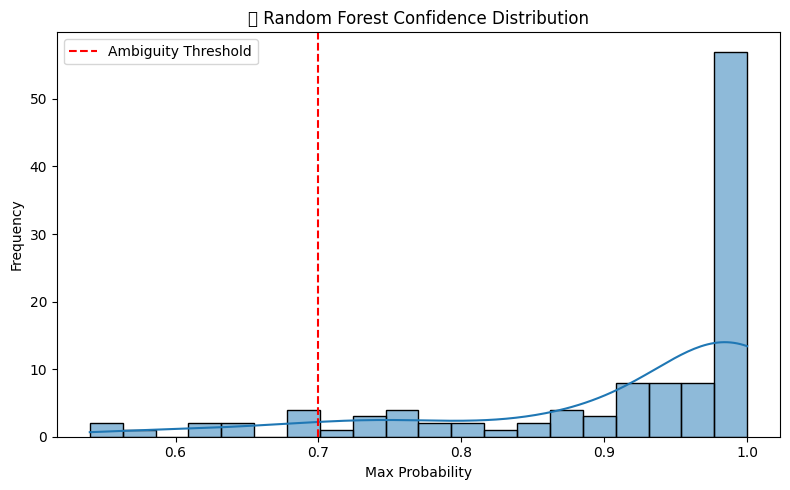

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# Confidence = max predicted prob
rf_confidences = np.max(y_proba, axis=1)

plt.figure(figsize=(8, 5))
sns.histplot(rf_confidences, bins=20, kde=True)
plt.axvline(confidence_threshold, color='red', linestyle='--', label='Ambiguity Threshold')
plt.title('🔍 Random Forest Confidence Distribution')
plt.xlabel('Max Probability')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()


/var/folders/nv/f6411f7j6h90mvg4_2mwkb8c0000gn/T/ipykernel_88787/3538703165.py:25: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/anaconda3/envs/qenv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


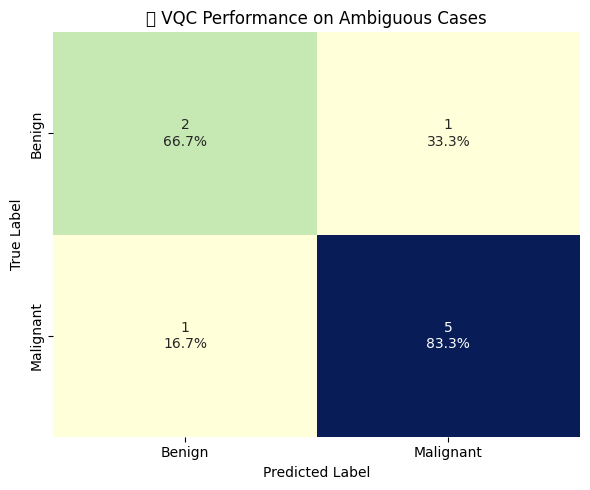

In [19]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion matrix
cm = confusion_matrix(y_ambiguous, y_vqc_pred)
labels = ["Benign", "Malignant"]  # or class 0/1 depending on your labeling

# Add % annotations
cm_sum = cm.sum(axis=1, keepdims=True)
cm_perc = np.round(cm / cm_sum.astype(float) * 100, 1)

annot = np.empty_like(cm).astype(str)
n_rows, n_cols = cm.shape
for i in range(n_rows):
    for j in range(n_cols):
        annot[i, j] = f"{cm[i, j]}\n{cm_perc[i, j]}%"

# Plot
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=annot, fmt='', cmap='YlGnBu', xticklabels=labels, yticklabels=labels, cbar=False)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("🎯 VQC Performance on Ambiguous Cases")
plt.tight_layout()
plt.show()


/var/folders/nv/f6411f7j6h90mvg4_2mwkb8c0000gn/T/ipykernel_88787/1350653307.py:33: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("Blues")
/var/folders/nv/f6411f7j6h90mvg4_2mwkb8c0000gn/T/ipykernel_88787/1350653307.py:54: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/anaconda3/envs/qenv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


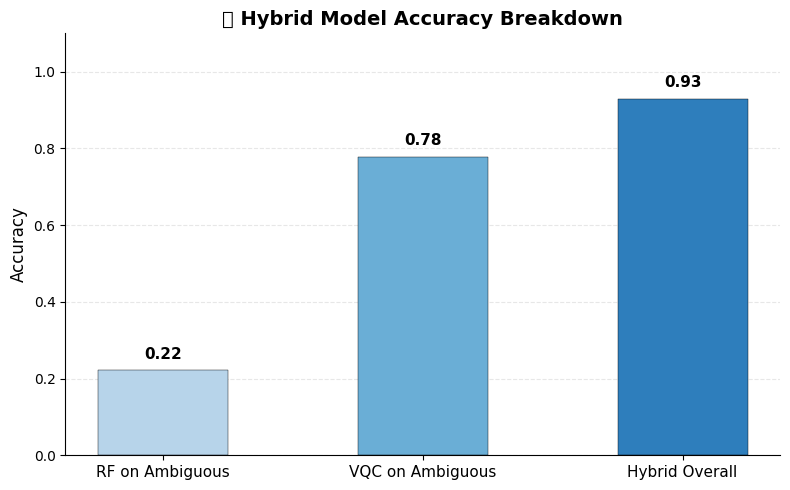

In [23]:
from sklearn.metrics import accuracy_score
import numpy as np

# 1. Get RF predicted class and predicted probabilities
rf_pred = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)

# 2. Define confidence threshold
confidence_threshold = 0.7  # or whatever value you used earlier

# 3. Identify ambiguous samples
rf_confidences = np.max(y_proba, axis=1)
ambiguous_indices = np.where(rf_confidences < confidence_threshold)[0]

# 4. Prepare hybrid predictions
hybrid_pred = rf_pred.copy()
hybrid_pred[ambiguous_indices] = vqc.predict(X_test[ambiguous_indices])

# 5. Accuracy metrics
y_ambiguous = y_test[ambiguous_indices]
rf_ambig_acc = accuracy_score(y_ambiguous, rf_pred[ambiguous_indices])
vqc_acc = accuracy_score(y_ambiguous, y_vqc_pred)
hybrid_acc = accuracy_score(y_test, hybrid_pred)

from matplotlib import pyplot as plt
from matplotlib import cm

labels = ["RF on Ambiguous", "VQC on Ambiguous", "Hybrid Overall"]
scores = [rf_ambig_acc, vqc_acc, hybrid_acc]
x = np.arange(len(labels))

# Use a soft blue gradient
cmap = cm.get_cmap("Blues")
colors = [cmap(0.3), cmap(0.5), cmap(0.7)]

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(x, scores, width=0.5, color=colors, edgecolor='black', linewidth=0.3)

for i, bar in enumerate(bars):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.03,
            f"{height:.2f}", ha='center', fontsize=11, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Accuracy", fontsize=12)
ax.set_title(" Hybrid Model Accuracy Breakdown", fontsize=14, weight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()


In [25]:
loss_history = []

def store_loss(weights, loss):
    loss_history.append(loss)

vqc = VQC(
    feature_map=feature_map,
    ansatz=ansatz,
    loss='cross_entropy',
    optimizer=COBYLA(maxiter=100),
    callback=store_loss
)


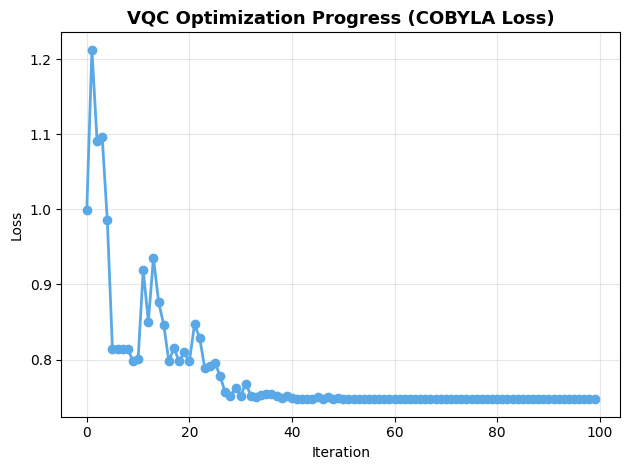

In [27]:
vqc.fit(X_ambiguous, y_ambiguous)

plt.plot(loss_history, marker='o', linewidth=2, color='#5AA9E6')
plt.title("VQC Optimization Progress (COBYLA Loss)", fontsize=13, weight='bold')
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### 🧠 VQC Optimization Insight

This graph illustrates how the Variational Quantum Classifier (VQC) optimized its internal parameters using the COBYLA algorithm over 100 iterations.  

As shown by the steadily decreasing loss curve, the model learned to better distinguish ambiguous cases before converging.  

Despite a small training set, this demonstrates how classical optimization effectively tuned the quantum circuit to improve performance.


/opt/anaconda3/envs/qenv/lib/python3.10/site-packages/qiskit/visualization/circuit/matplotlib.py:266: FutureWarning: The default matplotlib drawer scheme will be changed to "iqp" in a following release. To silence this warning, specify the current default explicitly as style="clifford", or the new default as style="iqp".
  self._style, def_font_ratio = load_style(self._style)


AttributeError: module 'matplotlib.pyplot' has no attribute 'tight_layout_'

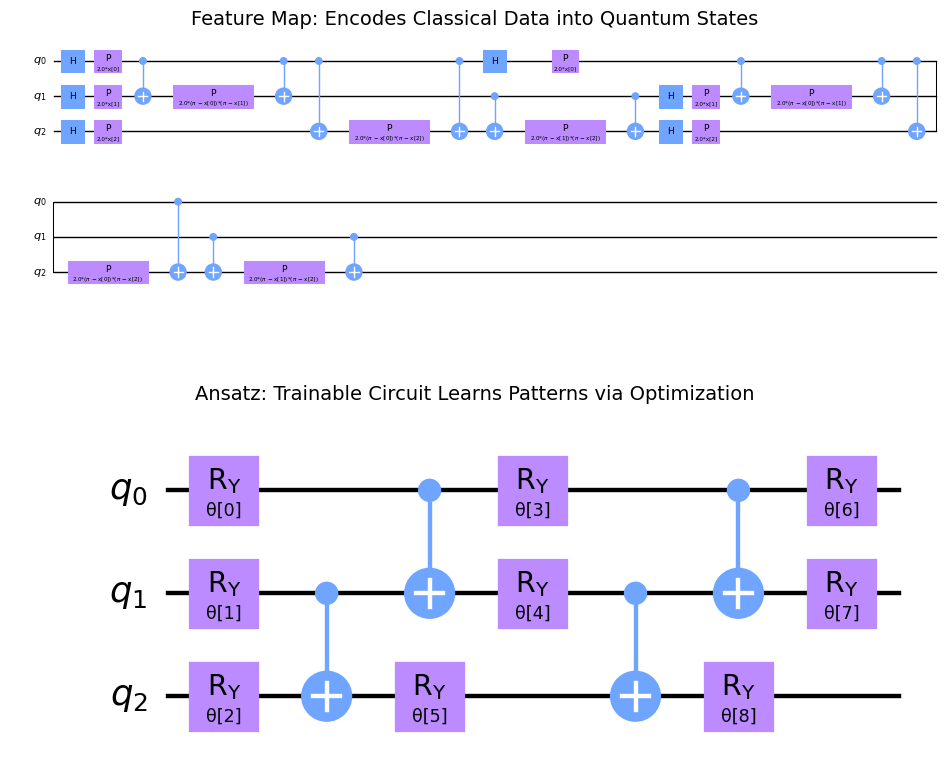

In [41]:
from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes
import matplotlib.pyplot as plt

num_qubits = 3

# Create & decompose for full detail
feature_map = ZZFeatureMap(feature_dimension=num_qubits, reps=2).decompose()
ansatz = RealAmplitudes(num_qubits=num_qubits, reps=2).decompose()

# Plot vertically
fig, axs = plt.subplots(2, 1, figsize=(12, 10))

feature_map.draw(output='mpl', ax=axs[0], cregbundle=False)
axs[0].set_title("Feature Map: Encodes Classical Data into Quantum States", fontsize=14)

ansatz.draw(output='mpl', ax=axs[1], cregbundle=False)
axs[1].set_title("Ansatz: Trainable Circuit Learns Patterns via Optimization", fontsize=14)

plt.tight_layout_


### This visualization breaks down the full quantum model: the **Feature Map** encodes classical input data into quantum states, while the **Ansatz** is a trainable circuit whose parameters are optimized during learning. Together, they form the core of the Variational Quantum Classifier (VQC), allowing it to capture complex patterns even with limited data.